# Exploratory Data Analysis (EDA)

## Package Import & Path Setting

In [5]:
from pathlib import Path
import pandas as pd
from pandas import DataFrame as df
import numpy as np
import matplotlib.pyplot as plt

# data split
from sklearn.model_selection import train_test_split

# feature analysis
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import (
    mutual_info_classif,
    mutual_info_regression,
    VarianceThreshold,
    f_classif,
    f_regression
)

# preprocessing & structure
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# baseline models
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



In [6]:
PROJECT_ROOT = Path.cwd().parents[0]
DATA_DIR = PROJECT_ROOT / "data" / "raw"

train_data_path = DATA_DIR / 'train.csv'
test_data_path = DATA_DIR / 'test.csv'


## Data Loading

In [7]:
train_raw_df = pd.read_csv(train_data_path)
test_raw_df = pd.read_csv(test_data_path)


## Train Data Analysis

In [8]:
train_raw_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
train_raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


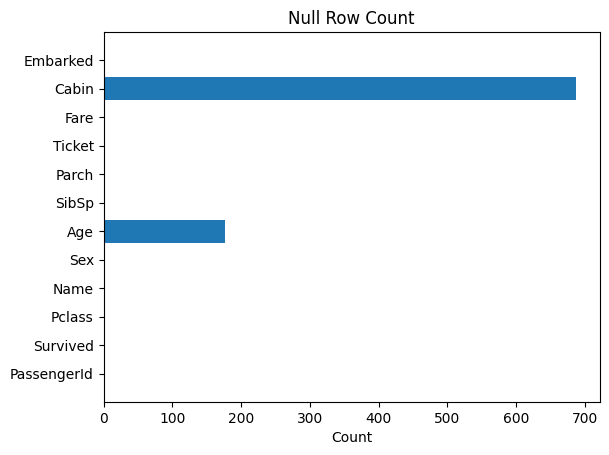

In [10]:
train_null_count = {}
for k in train_raw_df.keys():
    null_num = train_raw_df.shape[0] - train_raw_df[k].count()
    train_null_count[k] = null_num

plt.barh(list(train_null_count.keys()), list(train_null_count.values()))
plt.title('Null Row Count')
plt.xlabel('Count')
plt.show()

**Data Dictionary**

| Variable  | Definition                                      | Key / Notes                                      |
|-----------|--------------------------------------------------|--------------------------------------------------|
| survival  | Survival                                         | 0 = No, 1 = Yes                                  |
| pclass    | Ticket class                                     | 1 = 1st, 2 = 2nd, 3 = 3rd                        |
| sex       | Sex                                              |                                                  |
| Age       | Age in years                                     | Fractional if < 1; estimated ages end with .5    |
| sibsp     | # of siblings / spouses aboard the Titanic       | Sibling = brother, sister, stepbrother, stepsister; Spouse = husband, wife (mistresses & fiancés ignored) |
| parch     | # of parents / children aboard the Titanic       | Parent = mother, father; Child = daughter, son, stepdaughter, stepson; Some children traveled only with a nanny (parch=0) |
| ticket    | Ticket number                                    |                                                  |
| fare      | Passenger fare                                   |                                                  |
| cabin     | Cabin number                                     |                                                  |
| embarked  | Port of Embarkation                              | C = Cherbourg, Q = Queenstown, S = Southampton   |

* `Pclass`,`Sex` and `Embarked`  needs to be transformed into one-hot
* columns to drop: `Name`, `Cabin` (too many missing values), `ticket`

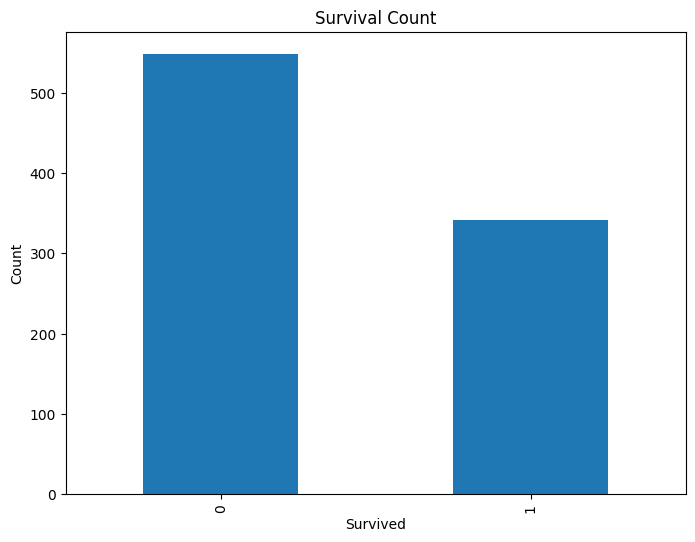

In [11]:
# Get value counts for both datasets
train_counts = train_raw_df['Survived'].value_counts().sort_index()

# Plot grouped bars
train_counts.plot(kind='bar', figsize=(8, 6))
plt.title('Survival Count')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()


The bar plot shows generally balanced label distribution.

In [12]:
train_raw_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Value Distribution

#### Categorical Features

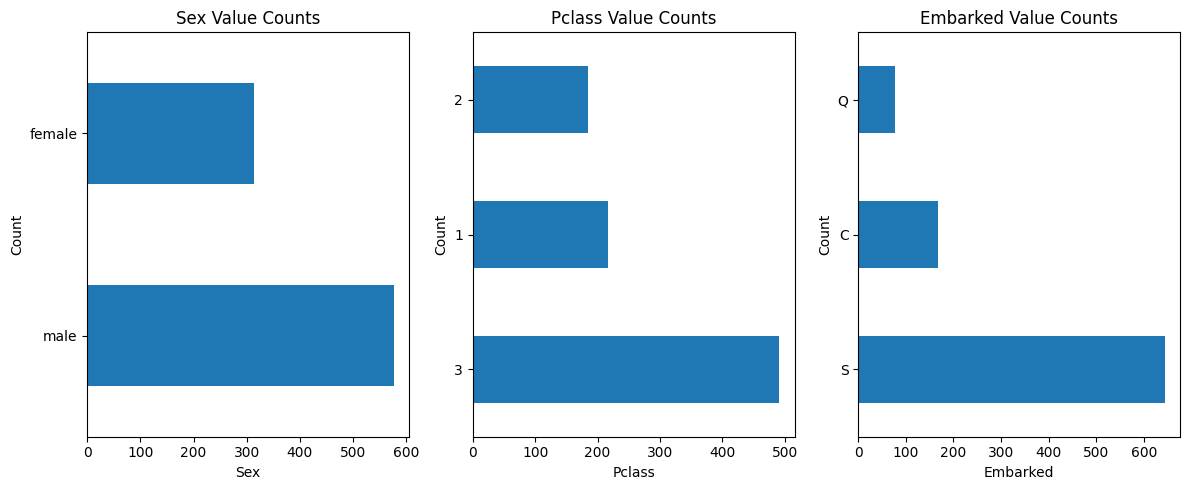

In [13]:
columns_to_plot = ['Sex', 'Pclass', 'Embarked']

fig, axes = plt.subplots(1, len(columns_to_plot), figsize=(12, 5))

for i, col in enumerate(columns_to_plot):
    counts = train_raw_df[col].value_counts()
    counts.plot(kind='barh', ax=axes[i])
    axes[i].set_title(f'{col} Value Counts')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

* The distribution of `Pclass` agrees with common sense that the cheapest class makes up the most counts
* The distribution of `Embarked` leans heavely toward one value

#### Numerical Features

In [14]:
train_raw_df[['Age', 'Fare', 'SibSp', 'Parch']].describe()

,Age,Fare,SibSp,Parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


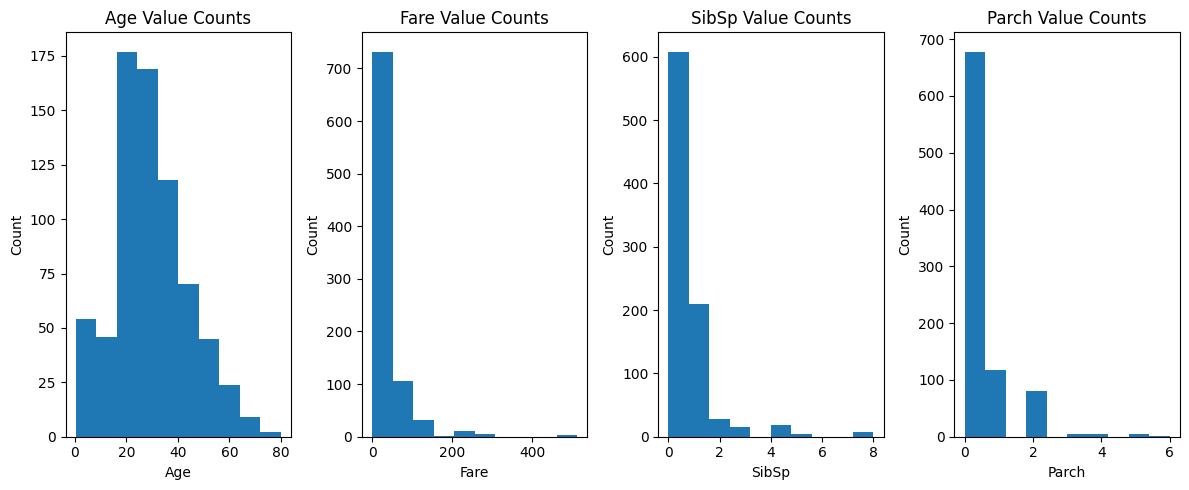

In [15]:
columns_to_plot = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(1, len(columns_to_plot), figsize=(12, 5))
col_bins = {}
for i, col in enumerate(columns_to_plot):
    n, bins, patches = axes[i].hist(train_raw_df[col].dropna())
    col_bins[col] = bins
    axes[i].set_title(f'{col} Value Counts')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

* `Age` looks like normal distribution
* `Fare` distribution is correlated with `Pclass`
* Strong shift in `SibSp` and `Parch` distribution

### Crosstab

#### Categorical Features

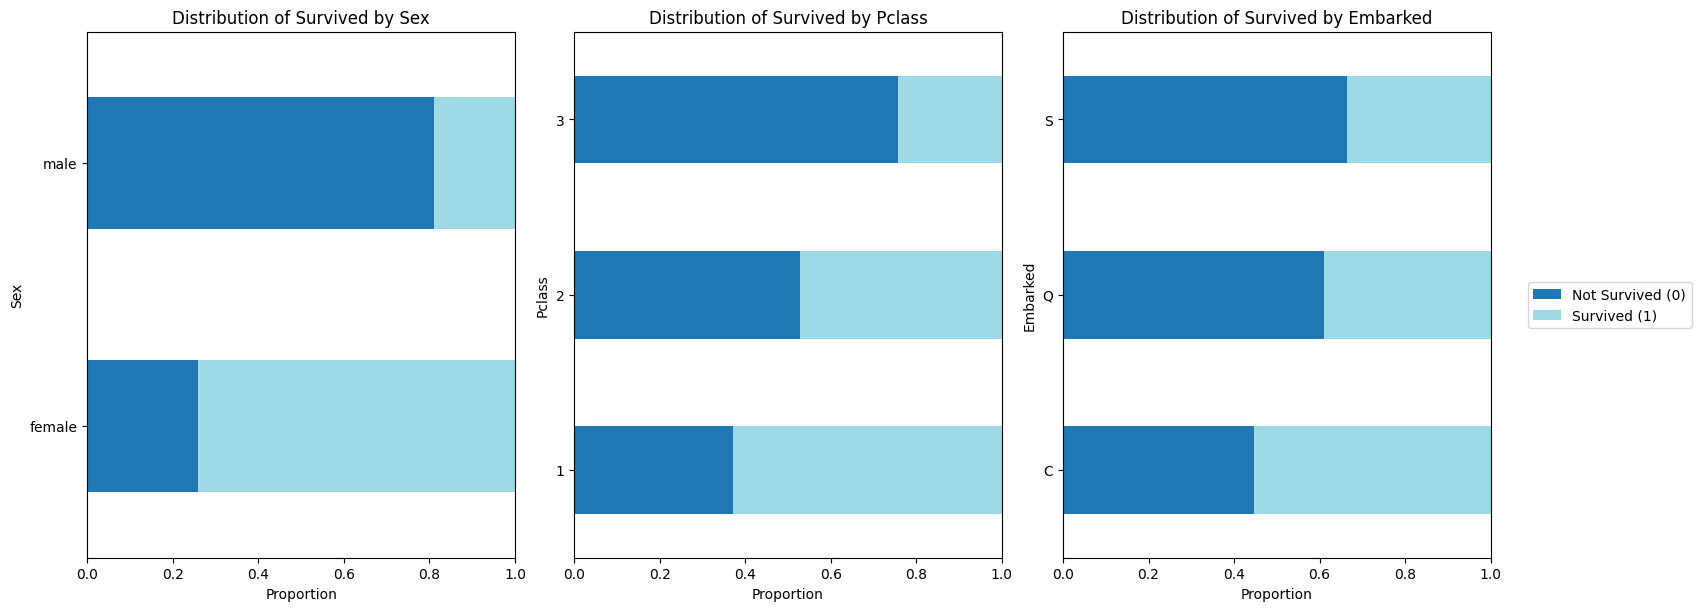

In [16]:
columns_to_plot = ['Sex', 'Pclass', 'Embarked']

fig, axes = plt.subplots(1, len(columns_to_plot), figsize=(15, 6), constrained_layout=True)

for i, col in enumerate(columns_to_plot):
    ax = axes[i] if len(columns_to_plot) > 1 else axes
    # rows = category values, columns = Survived labels; normalize by row to show distribution per value
    ct = pd.crosstab(train_raw_df[col], train_raw_df['Survived'], normalize='index').fillna(0)
    # nicer column labels
    ct.columns = ['Not Survived (0)', 'Survived (1)'] if set(ct.columns) == {0, 1} else [str(c) for c in ct.columns]
    ct.plot(kind='barh', stacked=True, ax=ax, cmap='tab20', legend=False)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Proportion')
    ax.set_title(f'Distribution of Survived by {col}')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,  
    loc="center left",
    bbox_to_anchor=(1.01, 0.5)
)

plt.show()

The crosstab shows that `Sex` has significant impact on the survival rate while the survival distribution of `Embarked` is close to normal.

#### Numerical Features

In [17]:
columns_to_plot = ['Age', 'Fare', 'SibSp', 'Parch']

col_bin_labels = {}

col_bins['Age'] = list(range(0, 90, 10))
col_bin_labels['Age'] = [f'{v}-{col_bins["Age"][i + 1]}' for i, v in enumerate(col_bins['Age'][:-1])]

col_bins['Fare'] = [0, 15, 30, 100, 150, np.inf]
col_bin_labels['Fare'] = ['0-15', '15-30', '30-100', '100-150', '150+']

col_bins['SibSp'] = [0, 1, 2, 3, 4, np.inf]
col_bin_labels['SibSp'] = ['1', '2', '3', '4', '4+']

col_bins['Parch'] = [0, 1, 2, 3, 4, np.inf]
col_bin_labels['Parch'] = ['1', '2', '3', '4', '4+']

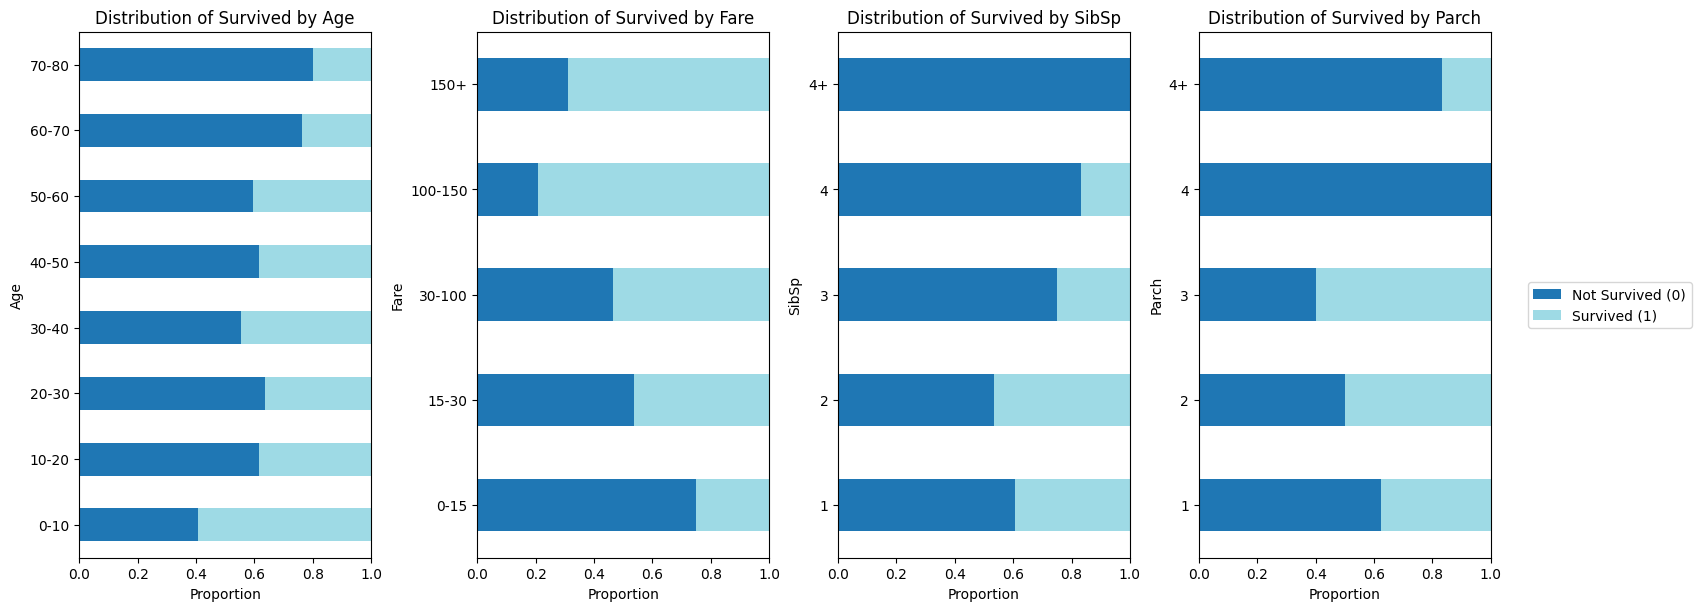

In [18]:

fig, axes = plt.subplots(1, len(columns_to_plot), figsize=(15, 6), constrained_layout=True)

for i, col in enumerate(columns_to_plot):
    bins = col_bins[col]
    labels = col_bin_labels[col]
    ax = axes[i] if len(columns_to_plot) > 1 else axes
    col_binned = pd.cut(train_raw_df[col], bins=bins, labels=labels, include_lowest=True)
    # rows = category values, columns = Survived labels; normalize by row to show distribution per value
    ct = pd.crosstab(col_binned, train_raw_df['Survived'], normalize='index').fillna(0)
    # nicer column labels
    ct.columns = ['Not Survived (0)', 'Survived (1)'] if set(ct.columns) == {0, 1} else [str(c) for c in ct.columns]
    ct.plot(kind='barh', stacked=True, ax=ax, cmap='tab20', legend=False)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Proportion')
    ax.set_title(f'Distribution of Survived by {col}')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,  
    loc="center left",
    bbox_to_anchor=(1.01, 0.5)
)

plt.show()

The distribution shows strong prediction in certain value range in each feature.

### Baseline Model Test

#### Split Data

In [19]:
train_df = train_raw_df.copy()
train_df = train_df.drop(columns=['Name', 'Cabin', 'Ticket', 'PassengerId', 'Survived'])
target = train_raw_df['Survived']
X_train, X_valid, y_train, y_valid = train_test_split(train_df, target, test_size=0.2, random_state=37, stratify=target)

#### Pre-processing

In [20]:

# Select categorical columns to encode
cat_cols = ['Pclass', 'Sex', 'Embarked']
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train_val_imp = num_imputer.fit_transform(X_train[num_cols])
X_train_cat_imp = cat_imputer.fit_transform(X_train[cat_cols])



scaler = StandardScaler()
X_train_val_scaled = scaler.fit_transform(X_train_val_imp)


# Initialize OneHotEncoder (drop='first' to avoid multicollinearity, sparse=False for DataFrame output)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Fit and transform the selected columns
X_train_cat_encd = encoder.fit_transform(X_train_cat_imp)

X_train_proc = pd.DataFrame(
    np.concatenate([X_train_val_scaled, X_train_cat_encd], axis=1),
    columns=num_cols + list(encoder.get_feature_names_out(cat_cols))
)

X_train_proc.head()


,Age,Fare,SibSp,Parch,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,-0.107060,-0.213262,-0.452552,-0.482670,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,-0.107060,-0.498892,-0.452552,-0.482670,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,-0.264947,-0.372521,0.420665,-0.482670,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
3,1.629700,4.226502,-0.452552,0.718943,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,-0.896496,-0.504319,-0.452552,-0.482670,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [21]:
# Validation Data
# Imputing
X_valid_val_imp = num_imputer.transform(X_valid[num_cols])
X_valid_cat_imp = cat_imputer.transform(X_valid[cat_cols])
# Scaling & Encoding
X_valid_val_scaled = scaler.transform(X_valid_val_imp)
X_valid_cat_encd = encoder.transform(X_valid_cat_imp)
# Final Data
X_valid_proc = pd.DataFrame(
    np.concatenate([X_valid_val_scaled, X_valid_cat_encd], axis=1),
    columns=num_cols + list(encoder.get_feature_names_out(cat_cols))
)

X_valid_proc.head()


,Age,Fare,SibSp,Parch,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,-0.107060,-0.501935,-0.452552,-0.482670,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,2.103362,-0.052031,-0.452552,-0.482670,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,-0.896496,-0.372521,-0.452552,0.718943,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
3,-0.343890,-0.501359,0.420665,-0.482670,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4,-0.107060,-0.515089,-0.452552,-0.482670,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0


#### Simple Model Training

In [26]:
# baseline model
model = LogisticRegression()
model.fit(X_train_proc, y_train)
pred = model.predict(X_valid_proc)
score = accuracy_score(y_valid, pred) 
# dummy model
dummy_model = DummyClassifier(strategy='most_frequent')
dummy_model.fit(X_train_proc, y_train)
dummy_pred = dummy_model.predict(X_valid_proc)
dummy_score = accuracy_score(y_valid, dummy_pred) 

print(f'Baseline Model Val Accuracy: {score:.4f}')
print(f'Dummy Model Val Accuracy: {dummy_score:.4f}')
print(f'Baseline Model Lift: {(score - dummy_score):.4f}')

feature_names = list(num_cols) + list(encoder.get_feature_names_out(cat_cols))
coefs = pd.Series(model.coef_[0], index=feature_names).sort_values(key=np.abs)
coefs_sq = np.pow(coefs, 2).sort_values(key=np.abs)

Baseline Model Val Accuracy: 0.7933
Dummy Model Val Accuracy: 0.6145
Baseline Model Lift: 0.1788


The baseline model shows significant lift over dummy (all guessing) model, indicating that it could be the initial choice.

#### Permutation Importance
Shuffle the features used in prediction to see the performance imapct, and use the result for the feature filtering.


In [23]:
%%time
result = permutation_importance(
    model,
    X_valid_proc,
    y_valid,
    scoring="accuracy",   # for Titanic baseline; consider "roc_auc" too
    n_repeats=30,
    random_state=42,
    n_jobs=1
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std,
}).sort_values("importance_mean")


perm_df.set_index('feature', inplace=True)



CPU times: total: 500 ms
Wall time: 502 ms


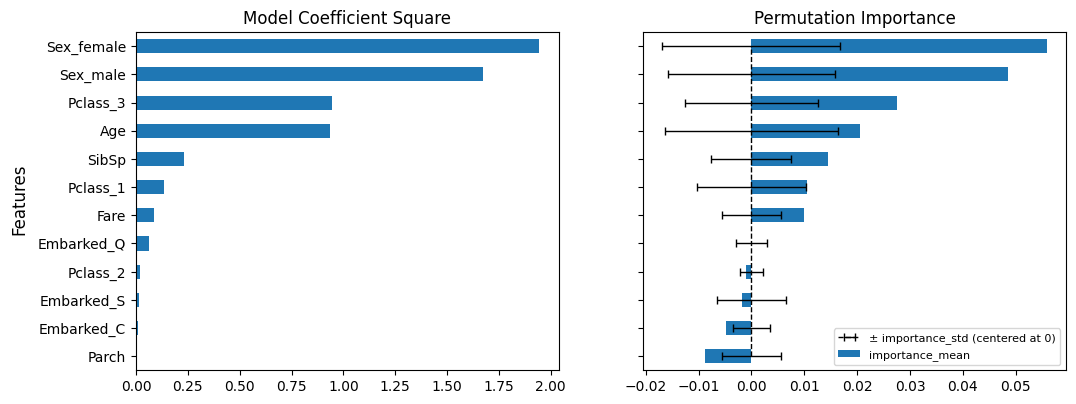

In [24]:

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
coefs_sq.plot(kind='barh', ax=ax[0])
ax[0].set_title('Model Coefficient Square')
ax[0].set_box_aspect(0.8)
ax[1].errorbar(x=np.zeros(len(perm_df)), y=np.arange(len(perm_df)), 
            xerr=perm_df['importance_std'], linewidth=1, linestyle='--', 
            color='black', ecolor='black', elinewidth=1, capsize=3,
            capthick=1, label='± importance_std (centered at 0)')
ax[1].set_title('Permutation Importance')
ax[1].set_box_aspect(0.8)
perm_df['importance_mean'].plot(kind='barh', ax=ax[1])
ax[1].set_ylabel('')
ax[1].legend(fontsize=8)
fig.supylabel('Features')
# plt.tight_layout()

plt.show()

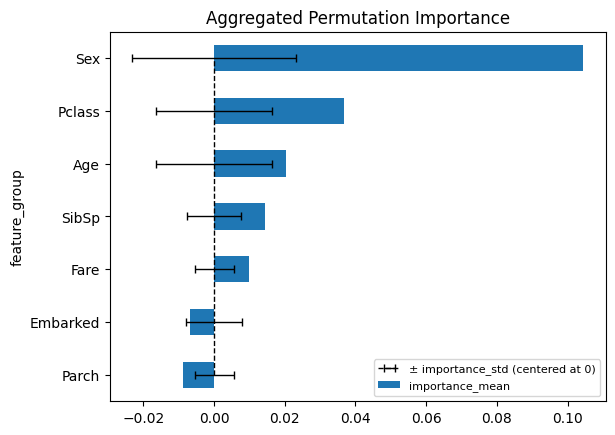

In [25]:
perm_df['feature_group'] = perm_df.index.str.split('_').str[0]
perm_group_agg_mean = perm_df.groupby('feature_group')['importance_mean'].sum().sort_values(ascending=True)
perm_group_agg_std = perm_df.groupby('feature_group')['importance_std'].apply(lambda x: np.sqrt(np.sum(x**2)))
perm_group_agg_std = perm_group_agg_std.reindex(perm_group_agg_mean.index)
fig, ax = plt.subplots()

ax.errorbar(x=np.zeros(len(perm_group_agg_mean)), y=np.arange(len(perm_group_agg_mean)), 
            xerr=perm_group_agg_std, linewidth=1, linestyle='--', 
            color='black', ecolor='black', elinewidth=1, capsize=3,
            capthick=1, label='± importance_std (centered at 0)')
ax.set_title('Aggregated Permutation Importance')
perm_group_agg_mean.plot(kind='barh', ax=ax)
ax.legend(fontsize=8)
plt.show()


* The result shows that `Sex`, `Pclass`, `Age`, `SibSp` are important features, while `Embarked` and `Parch` have little or even negative impact on model performance.
* Features to be considerd filtered in next stage: `Embarked`, `Parch`